# Implicit Funciton toolboox for geophysics

If we can fit a grid (or point data?) to a SIREN, we can operate directly on the Neural Network representation.


In [ ]:
from pathlib import Path

import colorcet as cc
import functorch
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import tifffile
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from mlnoddy import merge_z_slices


(200, 200, 50)


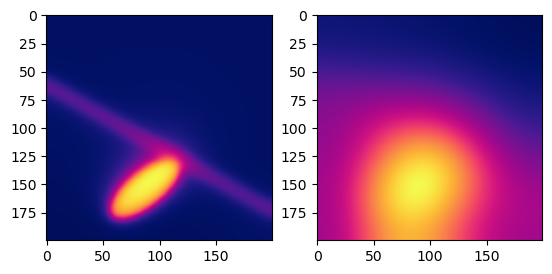

In [ ]:
dir_path = Path("D:/luke/data_source/Forward_models_xyz/")

def merge_z_slices(dir_path: str, idx: int = 0, n: int = 50):
    """Merge multiple Noddy forward models into a single 3D array
    For example, create a 200x200x200 volume of synthetic measurements.
    Args:
        dir_path: Path to directory to merge all .mag (and .grv)
        idx: Which model dir to load
        n: number of files to include, i.e. number of slices
    """

    dir_path = Path(dir_path)

    mag_files = sorted(list(dir_path.glob("*"))[idx].glob("*.mag"))[:n]
    grv_files = sorted(list(dir_path.glob("*"))[idx].glob("*.grv"))[:n]

    # get x y extent from header
    _, xlen, ylen, _ = mag_files[0].read_text().splitlines()[3].split()
    zlen = len(mag_files)

    return np.stack(
        [np.genfromtxt(f, dtype=np.float32, skip_header=8) for f in mag_files], axis=-1
    )


mag_vol = merge_z_slices(dir_path, idx=1)
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(mag_vol[:, :, 0], cmap=cc.cm.CET_L8)
plt.subplot(1, 2, 2)
plt.imshow(mag_vol[:, :, -1], cmap=cc.cm.CET_L8)
print(mag_vol.shape)

In [4]:
# All this cell from Sitzmann et al SIREN colab notebook, or their github repo
# LS added 3rd (z) dimension (upwards)


def get_mgrid(sidelen, z, dim=3):
    """Generates a flattened grid of ((x,y,z),...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int
    z: np.array(), raw sample height data. unnormalised at this stage.
    """
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors, indexing="ij"), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid


class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.

    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a
    # hyperparameter.

    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)

    def __init__(
        self, in_features, out_features, bias=True, is_first=False, omega_0=30
    ):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first

        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)

        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                self.linear.weight.uniform_(
                    -np.sqrt(6 / self.in_features) / self.omega_0,
                    np.sqrt(6 / self.in_features) / self.omega_0,
                )

    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))

    def forward_with_intermediate(self, input):
        # For visualization of activation distributions
        intermediate = self.omega_0 * self.linear(input)
        return torch.sin(intermediate), intermediate


class Siren(nn.Module):
    def __init__(
        self,
        in_features,
        hidden_features,
        hidden_layers,
        out_features,
        outermost_linear=False,
        first_omega_0=30,
        hidden_omega_0=30.0,
    ):
        super().__init__()

        self.net = []
        self.net.append(
            SineLayer(
                in_features, hidden_features, is_first=True, omega_0=first_omega_0
            )
        )

        for i in range(hidden_layers):
            self.net.append(
                SineLayer(
                    hidden_features,
                    hidden_features,
                    is_first=False,
                    omega_0=hidden_omega_0,
                )
            )

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)

            with torch.no_grad():
                final_linear.weight.uniform_(
                    -np.sqrt(6 / hidden_features) / hidden_omega_0,
                    np.sqrt(6 / hidden_features) / hidden_omega_0,
                )

            self.net.append(final_linear)
        else:
            self.net.append(
                SineLayer(
                    hidden_features,
                    out_features,
                    is_first=False,
                    omega_0=hidden_omega_0,
                )
            )

        self.net = nn.Sequential(*self.net)

    def forward(self, coords):
        # coords = (
        #     coords.clone().detach().requires_grad_(True)
        # )  # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output, coords

    def forward_with_activations(self, coords, retain_grad=False):
        """Returns not only model output, but also intermediate activations.
        Only used for visualizing activations later!"""
        activations = OrderedDict()

        activation_count = 0
        x = coords.clone().detach().requires_grad_(True)
        activations["input"] = x
        for i, layer in enumerate(self.net):
            if isinstance(layer, SineLayer):
                x, intermed = layer.forward_with_intermediate(x)

                if retain_grad:
                    x.retain_grad()
                    intermed.retain_grad()

                activations[
                    "_".join((str(layer.__class__), "%d" % activation_count))
                ] = intermed
                activation_count += 1
            else:
                x = layer(x)

                if retain_grad:
                    x.retain_grad()

            activations["_".join((str(layer.__class__), "%d" % activation_count))] = x
            activation_count += 1

        return activations


def gradient(u, xyz, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(u)
    grad = torch.autograd.grad(u, [xyz], grad_outputs=grad_outputs, create_graph=True)[
        0
    ]
    return grad


def divergence(u, xyz):
    div = 0.0
    for i in range(u.shape[-1]):
        div += torch.autograd.grad(
            u[..., i], xyz, torch.ones_like(u[..., i]), create_graph=True
        )[0][..., i : i + 1]
    return div


def laplace(u, xyz):
    grad = gradient(u, xyz)
    return divergence(grad, xyz)


def s_jacobian(u, xyz):
    """jacobian of u wrt x"""
    meta_batch_size, num_observations = u.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, u.shape[-1], xyz.shape[-1]).to(
        u.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(u.shape[-1]):
        # calculate dydx over batches for each feature value of y
        u_flat = u[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            u_flat, xyz, torch.ones_like(u_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status

In [16]:
class PointData3D(Dataset):
    """Construct a dataset for SIREN comprising 3D point coordinates
    and point values
    """

    def __init__(self, xyz_dir, idx):
        super().__init__()
        self.xyz_dir = xyz_dir
        self.vol = merge_z_slices(xyz_dir, idx=idx)
        self.coords = self.get_mgrid()
        self.pixels = torch.from_numpy(self.vol).view(-1, 1)

    def get_mgrid(self):
        tensors = tuple((torch.linspace(-1, 1, steps=s) for s in self.vol.shape))
        coords = torch.stack(torch.meshgrid(*tensors, indexing="ij"), dim=-1)
        coords = coords.reshape(-1, len(tensors)).unsqueeze(0)
        return coords

    def __len__(self):
        return 1  # This is an Implicit Function to overfit 1 sample

    def _normalise(self, a=-1, b=1):
        """Normalise between upper and lower -1 and 1"""
        self.a = a
        self.b = b
        self._min = self.grid.min()
        self._max = self.grid.max()
        self.grid = (b - a) * ((self.grid - self._min) / (self._max - self._min)) + a
        self.pixels = self.grid

    def _unnormalise(self, data):
        return (data - self.a) * (
            (self._max - self._min) / (self.b - self.a)
        ) + self._min

    def __getitem__(self, idx):
        if idx > 0:
            raise IndexError
        return self.coords, self.pixels


d = PointData3D("D:/luke/data_source/Forward_models_xyz/", 1)

Explicit function: $$u(x,y,z) = \sin(x+y+z) + \cos(x-y-z)$$

x and y and z partial derivatives:
$$\frac{\partial{u(x,y,z)}}{\partial{x}} = \cos(x+y+z) - \sin(x-y-z)$$ 
$$\frac{\partial{u(x,y,z)}}{\partial{y}} = \cos(x+y+z) + \sin(x-y-z)$$
$$\frac{\partial{u(x,y,z)}}{\partial{z}} = \cos(x+y+z) + \sin(x-y-z)$$

In [17]:
# ## Custom Function sample:
# %matplotlib inline

# def cust_fn(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     u = a * (np.sin(x + y + z) + np.cos(x - y - z))
#     return (x, y, z, u)


# def cust_fn_grad(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     dudx = a * (np.cos(x + y + z) - np.sin(x - y - z))
#     dudy = a * (np.sin(x - y - z) + np.cos(x + y + z))
#     dudz = a * (np.sin(x - y - z) + np.cos(x + y + z))

#     return (dudx, dudy, dudz)

# rng = np.random.default_rng()

# def plt_3d(fig: plt.Figure, x: np.ndarray, y: np.ndarray, z: np.ndarray, u: np.ndarray):
#    fig = plt.figure(figsize=(5, 5), constrained_layout=True)

#     ax = fig.add_subplot(projection="3d")

#     colors = np.empty(200,200,200, dtype=object)

#     colors[X] = 'red'
#     colors[Y] = 'blue'
#     colors[Z] = 'green'

#     ax.set(xlabel="x", ylabel="y", zlabel="z")
#     ax.set_aspect("equal")

#     plt.show()


# x, y, z, u = cust_fn(a=1, l=1)
# dudx, dudy, dudz = cust_fn_grad(a=1, l=1)

# fig = plt.figure(figsize=(5, 5), constrained_layout=True)
# plt.subplot(221)
# plt.title("u")
# plt_3d(fig, x, y, z, u)

# # plt.subplot(222)
# # plt.title("dudz")
# # plt_3d(fig, x, y, z, dudz)
# # plt.subplot(223)
# # plt.title("dudx")
# # plt_3d(fig, x, y, z, dudx)
# # plt.subplot(224)
# # plt.title("dudy")
# # plt_3d(fig, x, y, z, dudy)

In [18]:
# print(x.shape)
# print(y.shape)
# print(z.shape)
# print(u.shape)

In [19]:
# mask = (u[..., :] > -0.1)
# masked_u = u.copy()
# masked_u[~mask] = np.nan

# fig = plt.figure(figsize=(5, 5), constrained_layout=True)

# ax = fig.add_subplot(projection="3d")

# colors = np.empty(200,200,200, dtype=object)

# colors[masked_u] = 'red'
# colors[Y] = 'blue'
# colors[Z] = 'green'

# ax.set(xlabel="x", ylabel="y", zlabel="z")
# ax.set_aspect("equal")

# plt.show()

In [20]:
dset = d
coords, pixels = dset.coords, dset.pixels
coords = coords.requires_grad_(True)
print(coords.shape)
print(pixels.shape)

# plt_cntr(dset.original_grid.squeeze())


torch.Size([1, 2000000, 3])
torch.Size([2000000, 1])


In [23]:
total_steps = 2000  # 4000  # Since the whole image is our dataset, this just means n gradient descent steps.
summary_steps = [1000000, total_steps - 1]

dataloader = DataLoader(dset, batch_size=1, pin_memory=True, num_workers=0)

device = "cuda"

img_siren = Siren(
    in_features=3,
    out_features=3,
    hidden_features=256,
    hidden_layers=3,
    outermost_linear=True,
)
img_siren.to(device)

model_input, ground_truth = next(iter(dataloader))
model_input, ground_truth = model_input.to(device), ground_truth.to(device)

optim = torch.optim.Adam(lr=5e-5, params=img_siren.parameters())
losses = []

for step in tqdm(range(total_steps)):
    model_output, coords = img_siren(model_input)
    loss = ((model_output - ground_truth) ** 2).mean()
    losses.append(loss.item())

    if step in summary_steps:
        print("Step %d, Total loss %0.6f" % (step, loss))
        img_grad = gradient(model_output, coords)
        u = model_output.detach().cpu().view(dset.s, dset.s)
        u = dset._unnormalise(u).numpy()
        #     img_laplacian = laplace(model_output, coords)
        plt.figure(constrained_layout=True, figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt_cntr(u)
        plt.subplot(1, 2, 2)
        plt.plot(losses)
        plt.semilogy()

    optim.zero_grad()
    loss.backward()
    optim.step()

# 600x600, 500 iters, 25 sec, BUT laplacian too much ram

  0%|          | 0/2000 [00:00<?, ?it/s]

RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


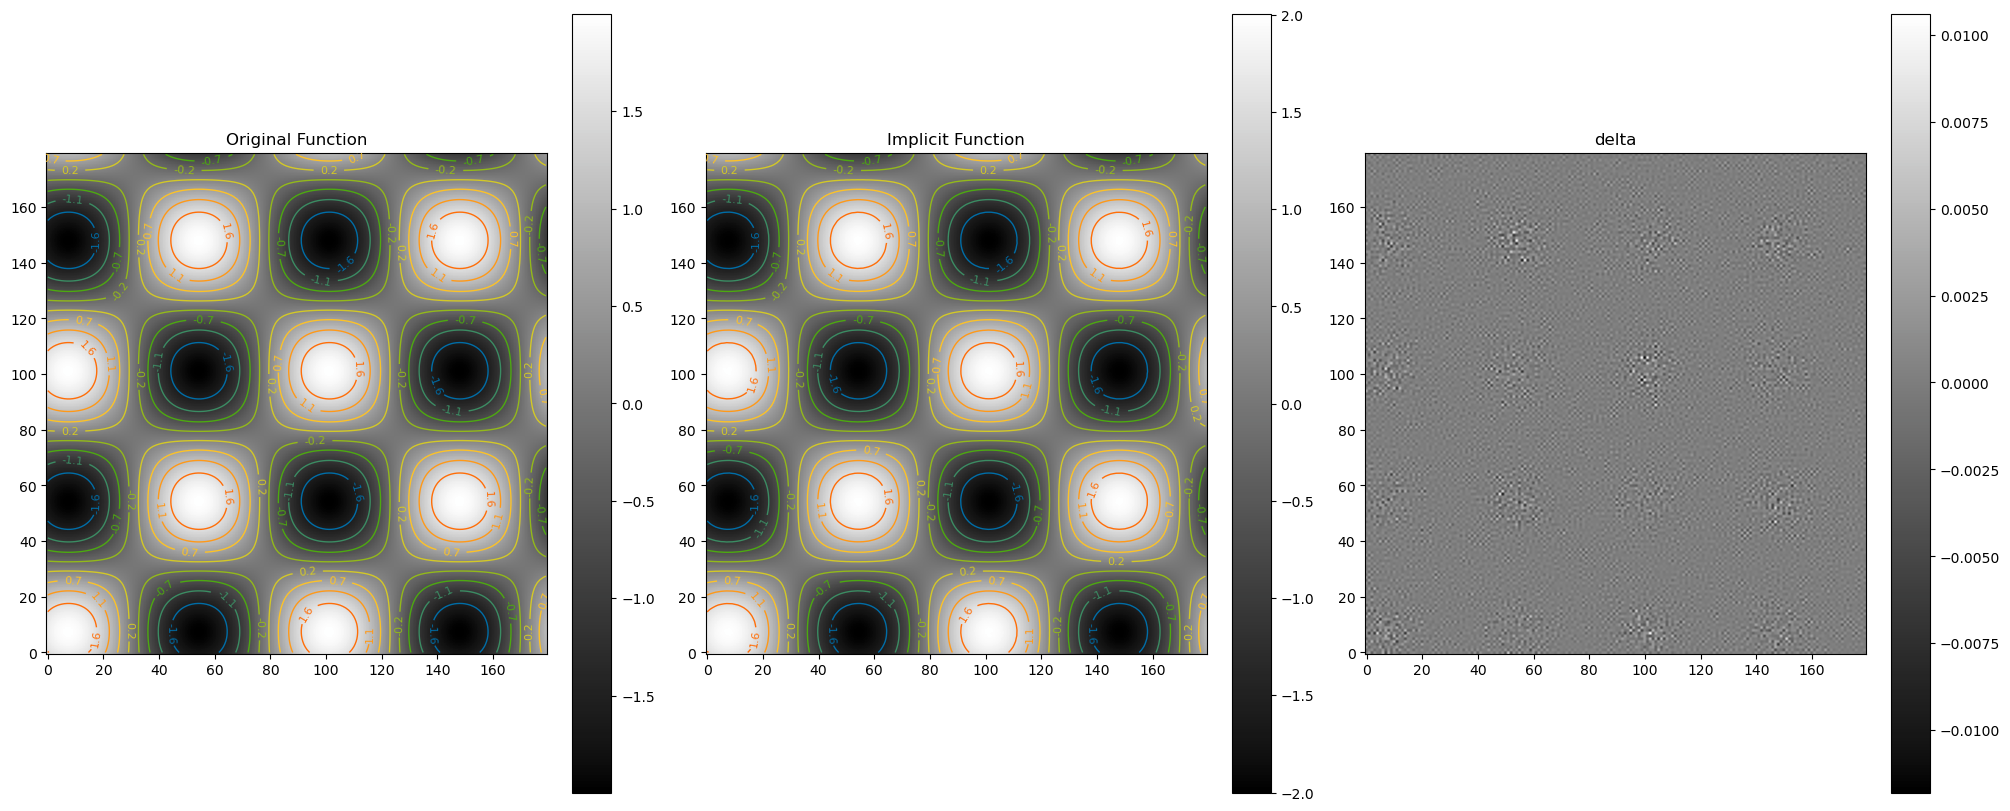

In [37]:
cx, cy, cu = cust_fn(a=a)

pred_u, xy_coord = img_siren(model_input)
pred_u = dset._unnormalise(pred_u)

plt.figure(constrained_layout=True, figsize=(20, 8))
plt.subplot(1, 3, 1)
plt.title("Original Function")
plt_cntr(cu)
plt.subplot(1, 3, 2)
plt.title("Implicit Function")
plt_cntr(pred_u.detach().cpu().view(dset.s, dset.s).numpy())

plt.subplot(1, 3, 3)
plt.title("delta")
plt.imshow(
    cu - pred_u.detach().cpu().view(dset.s, dset.s).numpy(),
    cmap=cc.cm.CET_L1,
    origin="lower",
)
plt.colorbar()

So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (u) which is the TMI at that x,y point.

There are several ways to calculate the Jacobian:  
1. `torch.autograd.grad`
1. `torch.autograd.functional.jacobian(vectorize=True)`
1. `functorch.jacrev`

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242

We want the Jacobian: $$J(x,y) = [\frac{\partial{u(x,y)}}{\partial{x}}, \frac{\partial{u(x,y)}}{\partial{y}}]$$

Where $$ u = f(x,y)\,,\, f:R^2 \to R^1$$
This is the special case where _the Jacobian matrix reduces to the row vector $${\displaystyle \nabla ^{\mathrm {T} }f}$$ this row vector of all first-order partial derivatives of f is the transpose of the gradient of f $${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$_



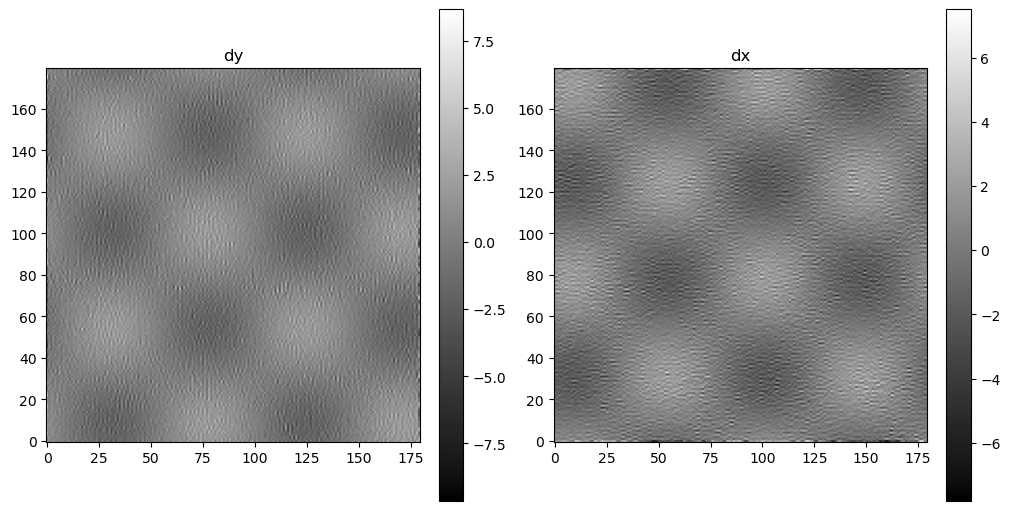

In [38]:
## Simple method for "Gradient", torch.autograd.grad
## The gradient is a special case of the Jacbian, when the function is scalar
## https://math.stackexchange.com/questions/1519367/difference-between-gradient-and-jacobian

model_output, _ = img_siren(model_input)
model_output = dset._unnormalise(model_output)
# model_input = dset._unnormalise(model_input)

grad = torch.autograd.grad(
    outputs=model_output,
    inputs=[model_input],
    grad_outputs=torch.ones_like(model_output),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
# grad = [grad[0]]
# print(f"{grad[0].shape = }")

# grad2 = torch.autograd.grad(
#     outputs=[grad[0]],
#     inputs=[model_input],
#     grad_outputs=torch.ones_like(grad[0]),
#     create_graph=True,
#     retain_graph=True,
#     allow_unused=True,
# )
# print(f"{grad2[0].shape = }")

dx, dy = grad[0].detach().reshape(dset.s, dset.s, 2).permute(2, 0, 1).cpu().numpy()

plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("dy")
plt.imshow(dx, cmap=cc.cm.CET_L1, origin="lower")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("dx")
plt.imshow(dy, cmap=cc.cm.CET_L1, origin="lower")
plt.colorbar()

In [39]:
model_output.shape

torch.Size([1, 32400, 1])

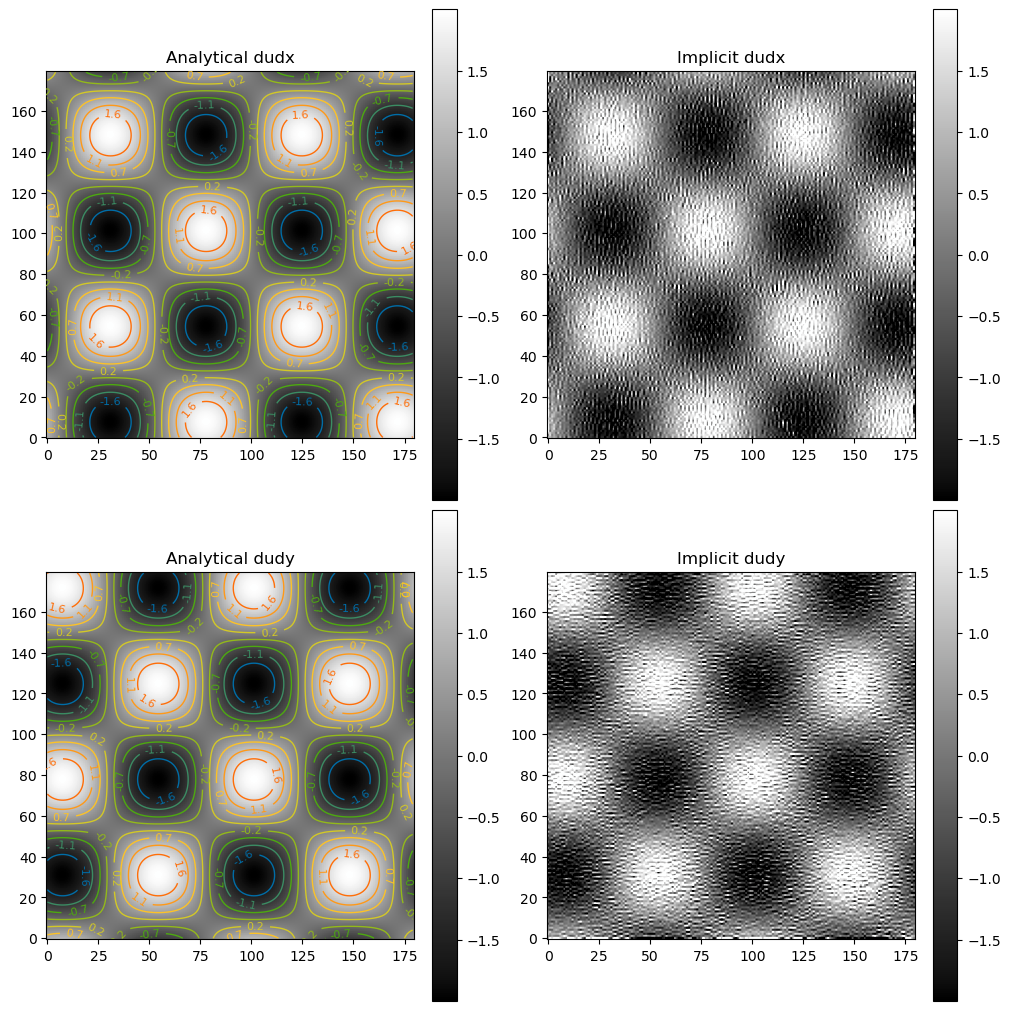

In [40]:
xmin = dudx.min()
xmax = dudx.max()
ymin = dudy.min()
ymax = dudy.max()

plt.figure(constrained_layout=True, figsize=(10, 10))
plt.subplot(221)
plt.title("Analytical dudx")
plt_cntr(dudx)
plt.subplot(222)
plt.title("Implicit dudx")
plt.imshow(dx, origin="lower", cmap=cc.cm.CET_L1, vmin=xmin, vmax=xmax)
plt.colorbar()
plt.subplot(223)
plt.title("Analytical dudy")
plt_cntr(dudy)
plt.subplot(224)
plt.title("Implicit dudy")
plt.imshow(dy, origin="lower", cmap=cc.cm.CET_L1, vmin=ymin, vmax=ymax)
plt.colorbar()

In [41]:
def gradients(pred_u, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return u.
    Generally, this is u = F(x,y)
    """
    return (
        torch.autograd.grad(
            outputs=pred_u,
            inputs=[xy_coord],
            grad_outputs=torch.ones_like(pred_u),
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]
        .detach()
        .reshape(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
        # .numpy()
    )


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dudy, dudx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dudx ** 2 + dudy ** 2)
    return torch.dstack((dudy, dudx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4
    It would be interesting to include u in the coords, and predict this
    """
    # (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    return NotImplementedError


def downward_continuation(du):
    """Downward Continuation, eqn 12.5
    args:
        - du: vertical distance to downward continue



    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError

In [42]:
pred_u, xy_coord = img_siren(model_input)
dudy, dudx = gradients(pred_u, model_input)
horiz_g = horizontal_gradient(dudy, dudx)

Text(0.5, 1.0, 'Horizontal Gradient')

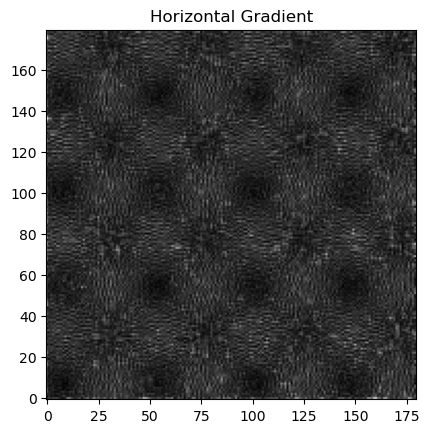

In [43]:
plt.imshow(horiz_g, cmap=cc.cm.CET_L1, origin="lower")
plt.title("Horizontal Gradient")

In [44]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom

In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(
    dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1, origin="lower"
)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_u.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$u$\delta$x")
caxx = axx.imshow(dudx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$u$\delta$y")
caxy = axy.imshow(dudy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")

In [ ]:
# ## SPARE BITS###


# # from functorch import vmap, vjp, jacrev

# # vmap(jacrev(img_siren))(model_input)
# ###

# j = (dudx, dudy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)#, vectorize=True)
# ###

# ## Sitzmann et al. method (non vectorised)
# meta_batch_size = pred_u.shape[0]  # only 1 tile
# num_observations = pred_u.shape[1]  # Num XYZ points,
# out_vecs = pred_u.shape[-1]  # num output channels, 1
# in_ch = xy_coord.shape[-1]  # num input channels, 2

# jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
#     pred_u.device
# )  # (meta_batch_size*num_points, 2, 2)
# for vec in range(out_vecs):
#     # calculate dydx over batches for each feature value of y
#     y_flat = pred_u[..., vec].view(-1, 1)
#     jac[:, :, vec, :] = torch.autograd.grad(
#         y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
#     )[0]

# ###

# jac2 = jac.squeeze().reshape(200,200,2).permute(2,0,1)[1]
# plt.imshow(jac2.detach().cpu().numpy())
# plt.colorbar()
# ###


# from functorch import vmap, vjp, jacrev

# def f(x):
#     return img_siren(x)

# j = jacrev(f)(model_input.squeeze())

# print(model_input.squeeze().shape)
# print(f"{j[0].shape=}")
# print(f"{j[1].shape=}")

# ###

# ## As of pytorch 1.13, we can now use functorch operations
# ## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# # from functorch import vmap, vjp, jacfwd, jacrev
# # torch.manual_seed(0)

# # img_siren

# # m = model_input.clone().requires_grad_()

# # cotangents = torch.eye(m.shape[1])
# # _, vjp_fn = vjp((img_siren), m)
# # vmap(vjp_fn)(cotangents)

# # # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # # btach_jac = ft_jacobian( )

# # model_output, coords = img_siren(model_input)
# # print(f"{model_input.shape=}")
# # print(f"{img_siren(model_input)[0].shape=}")
# # print(f"{img_siren(model_input)[1].shape=}")

# # j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# # j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# # j3 = j2.permute(2,0,1)

# # j2.shape
# # j.squeeze()[1].reshape(s, s, 2).shape